# AlphaEarth vs. Random Embeddings — Visualising Spatial Structure

Companion notebook to *"Site Identity or Environmental Signal?"*.

**Goal.** Show — visually — that AlphaEarth embeddings (AEE) carry spatial
structure (geographically close locations → similar embeddings), while
random per-location embeddings do not.  This directly motivates the paper's
claim that gains from location context under *temporal* generalisation come
mostly from site identity, while AEE provides additional **transferable**
environmental structure that matters under *spatial* and *spatiotemporal*
shift.

**Sections**
1. Load paper datasets (observation metadata only)
2. Load AlphaEarth embeddings + build random baselines
3. Geographic distribution of observations
4. Cosine similarity "vector fields" — AEE vs Random from reference sites
5. 2D PCA projection coloured by latitude
6. Similarity vs. geographic distance decay
7. Pairwise similarity matrices per region

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from pysephone.constants import KEY_LAT, KEY_LON
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.data.alphaearth import (
    AlphaEarthEmbeddingStore, _default_h5_path, _stable_location_id,
)

DATASETS_PAPER = {
    'GMU_Cherry_Japan':       ('Japan cherry (P. yedoensis)',    'gmu_0'),
    'GMU_Cherry_Switzerland': ('Swiss cherry (P. avium)',        'gmu_1'),
    'GMU_Cherry_South_Korea': ('S. Korea cherry (P. yedoensis)', 'gmu_2'),
    'PEP725_Apple':           ('Apple (Malus x domestica)',      'BBCH_60'),
    'PEP725_Pear':            ('Pear (Pyrus communis)',          'BBCH_60'),
    'PEP725_Cherry':          ('Cherry (Prunus avium)',          'BBCH_60'),
    'PEP725_Plum':            ('Plum (Prunus domestica)',        'BBCH_60'),
}

EMBED_DIM     = 64
RANDOM_SEED   = 0
AEE_PRECISION = 6

## 1. Load paper datasets (observation metadata only)

No weather download: we only need ``(loc_id, lat, lon)`` per unique station
for the embedding analysis.

In [2]:
cal = Calendar()

rows = []
for key, (label, obs_key) in DATASETS_PAPER.items():
    try:
        ds = Dataset.load(key, calendar=cal, feature_providers=[])
    except Exception as e:
        print(f'[skip] {key}: {e}')
        continue

    seen = set()
    for sample in ds.iter_items():
        loc = (sample['src'], sample['loc_id'])
        if loc in seen:
            continue
        seen.add(loc)
        rows.append({
            'dataset':       key,
            'dataset_label': label,
            'src':           sample['src'],
            'loc_id':        sample['loc_id'],
            'lat':           float(sample[KEY_LAT]),
            'lon':           float(sample[KEY_LON]),
        })

df_loc = pd.DataFrame(rows).drop_duplicates(['dataset', 'loc_id']).reset_index(drop=True)
print(df_loc.groupby('dataset').agg(n_locations=('loc_id', 'count')))

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 17427.02it/s]


                        n_locations
dataset                            
GMU_Cherry_Japan                 82
GMU_Cherry_South_Korea           52
GMU_Cherry_Switzerland           67
PEP725_Apple                    836
PEP725_Cherry                  1095
PEP725_Pear                     590
PEP725_Plum                     622


## 2. Load AlphaEarth embeddings + random baselines

For each location, load all available annual embeddings from the HDF5 store
and take the element-wise mean across years to obtain a single
time-invariant 64-D vector per location — matching the paper's construction.

## 2b. Fetch elevation for every location

Uses the OpenMeteo Elevation API via `ElevationFeatures` (SRTM / COP30, ~30 m
DEM). Cached to disk at `data/products/elevation/elevations.json` — repeat
runs do not re-hit the API.

In [3]:
from pysephone.data.elevation import fetch_elevations

unique_coords = df_loc[['lat', 'lon']].drop_duplicates().to_records(index=False).tolist()
elev_by_coord = fetch_elevations(unique_coords, verbose=True)

def _lookup_elev(row):
    key = (round(row.lat, 4), round(row.lon, 4))
    return elev_by_coord.get(key, np.nan)

df_loc['elev'] = [_lookup_elev(r) for r in df_loc.itertuples()]
print(f'Elevation range: {df_loc["elev"].min():.0f} – {df_loc["elev"].max():.0f} m  '
      f'({df_loc["elev"].isna().sum()} missing)')

Elevation range: -1 – 2165 m  (0 missing)


In [4]:
store = AlphaEarthEmbeddingStore(_default_h5_path())

def mean_aee_for_point(lat: float, lon: float):
    loc_id = _stable_location_id(lat, lon, precision=AEE_PRECISION)
    with h5py.File(store.h5_path, 'r') as f:
        path = f'v1/locations/{loc_id}/embeddings'
        if path not in f:
            return None
        vecs = np.stack([np.asarray(v[...], dtype=np.float32) for v in f[path].values()])
    return vecs.mean(axis=0) if len(vecs) else None

aee_vecs, missing = [], 0
for _, row in df_loc.iterrows():
    v = mean_aee_for_point(row.lat, row.lon)
    if v is None:
        missing += 1
        aee_vecs.append(np.full(EMBED_DIM, np.nan, dtype=np.float32))
    else:
        aee_vecs.append(v)
df_loc['aee'] = aee_vecs

rng = np.random.default_rng(RANDOM_SEED)
df_loc['rand'] = [rng.standard_normal(EMBED_DIM).astype(np.float32) for _ in range(len(df_loc))]

has_aee = df_loc['aee'].apply(lambda v: not np.isnan(v).any())
print(f'AEE coverage: {has_aee.sum()}/{len(df_loc)} locations  ({missing} missing)')

AEE coverage: 3135/3344 locations  (209 missing)


## 3. Geographic distribution of observations

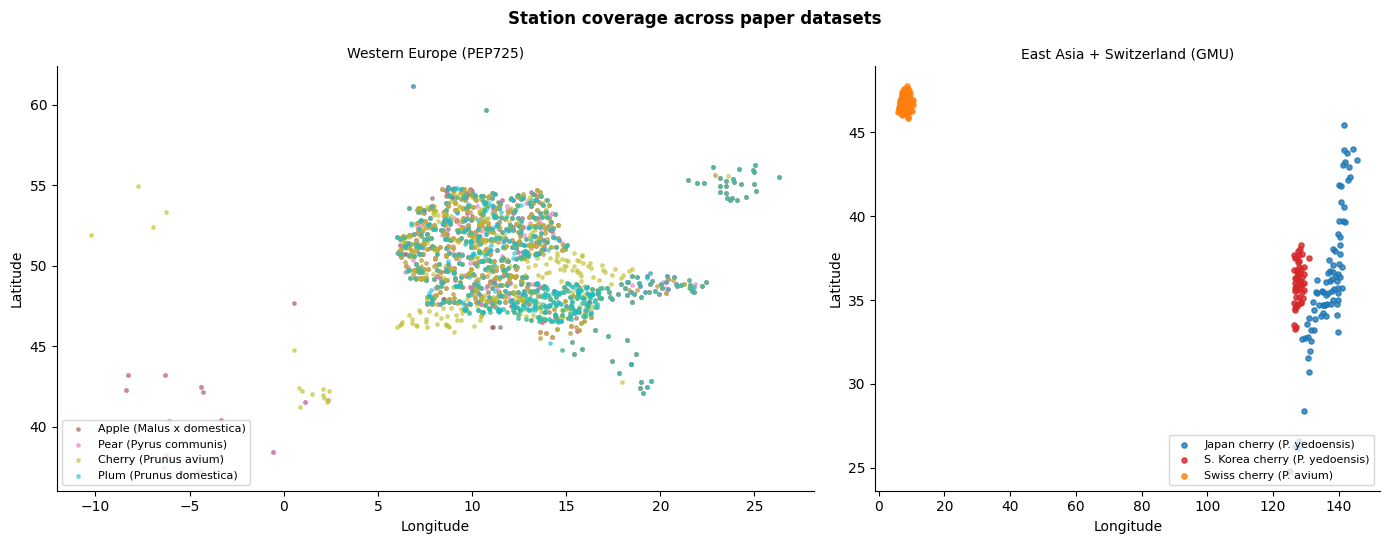

In [5]:
dataset_colors = dict(zip(
    DATASETS_PAPER.keys(),
    plt.cm.tab10(np.linspace(0, 1, len(DATASETS_PAPER))),
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1.5, 1]})
fig.suptitle('Station coverage across paper datasets', fontsize=12, fontweight='bold')

ax = axes[0]
for key in DATASETS_PAPER:
    if not key.startswith('PEP725'):
        continue
    sub = df_loc[df_loc['dataset'] == key]
    ax.scatter(sub['lon'], sub['lat'], s=6, alpha=0.5,
               color=dataset_colors[key], label=DATASETS_PAPER[key][0])
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Western Europe (PEP725)', fontsize=10)
ax.legend(fontsize=8, loc='lower left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
for key in ('GMU_Cherry_Japan', 'GMU_Cherry_South_Korea', 'GMU_Cherry_Switzerland'):
    sub = df_loc[df_loc['dataset'] == key]
    if sub.empty: continue
    ax.scatter(sub['lon'], sub['lat'], s=14, alpha=0.8,
               color=dataset_colors[key], label=DATASETS_PAPER[key][0])
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('East Asia + Switzerland (GMU)', fontsize=10)
ax.legend(fontsize=8, loc='lower right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

## 4. Cosine similarity vector fields (main figure)

Pick a reference station, compute cosine similarity between its embedding
and every other station's embedding, and plot on the map coloured by
similarity.

**AEE should produce spatially coherent regions of similarity;
Random should be noise.**

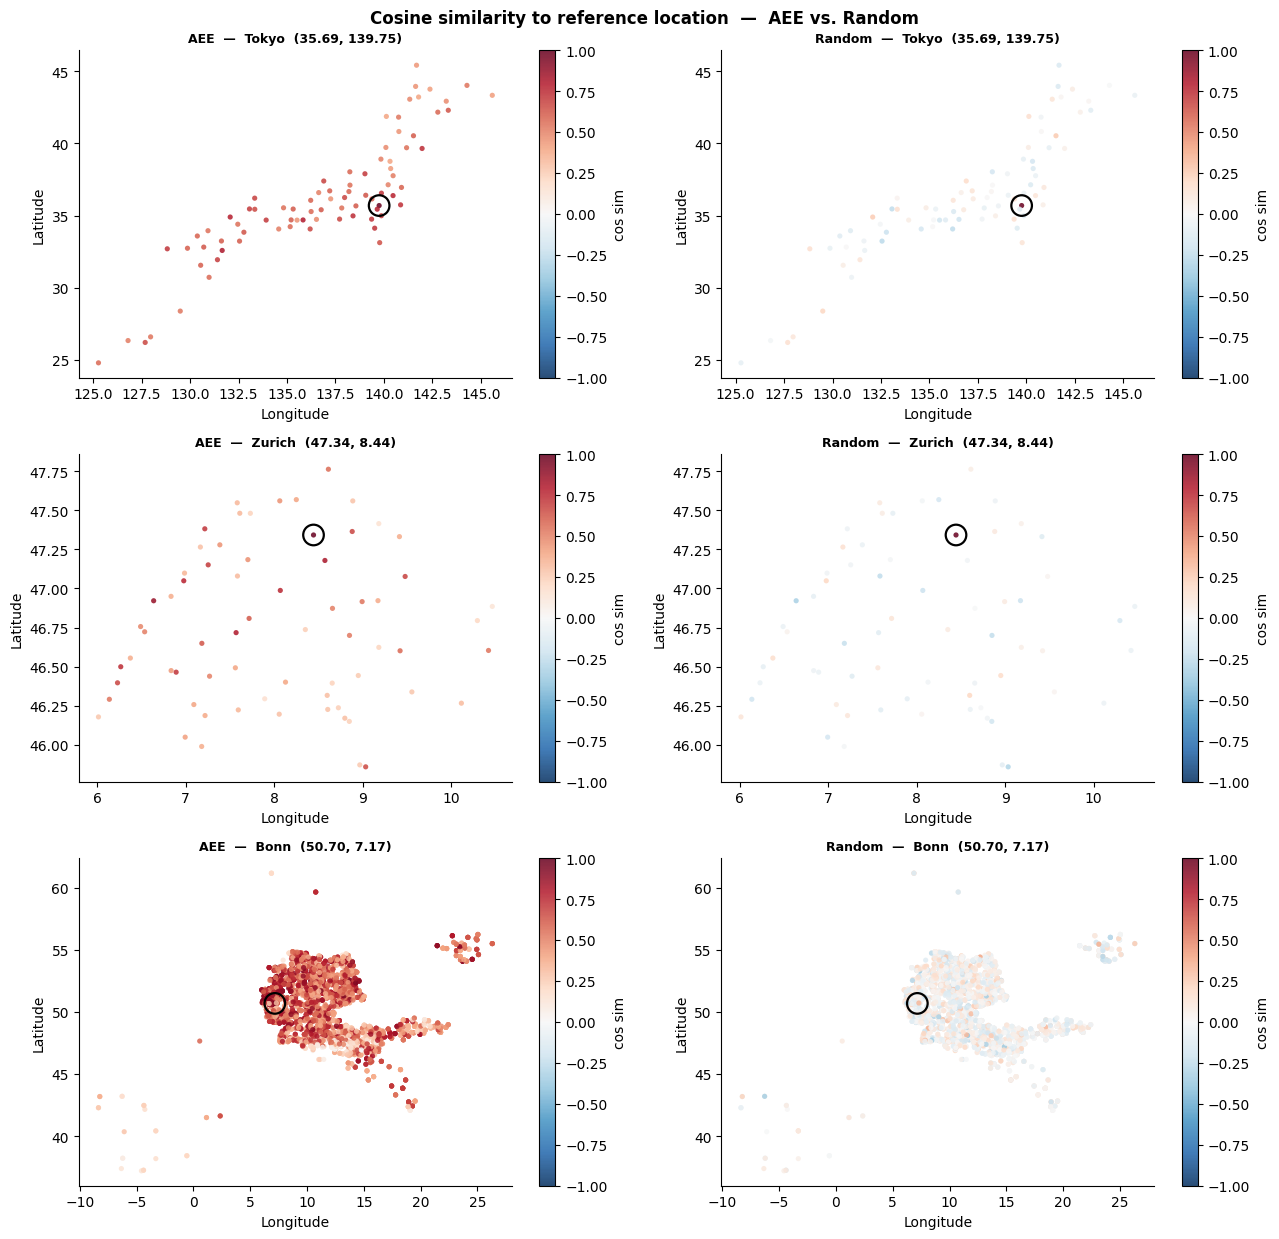

In [6]:
def cos_sim(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = a / (np.linalg.norm(a) + 1e-12)
    b = b / (np.linalg.norm(b, axis=-1, keepdims=True) + 1e-12)
    return b @ a


def nearest_loc(target_lat, target_lon, mask=None) -> int:
    d = df_loc[mask] if mask is not None else df_loc
    return int(((d['lat'] - target_lat)**2 + (d['lon'] - target_lon)**2).idxmin())


def plot_cosim_map(ax, scope_mask, ref_ix, emb_key, title, cmap='RdBu_r'):
    d = df_loc[scope_mask].reset_index(drop=True)
    ref_vec = df_loc.loc[ref_ix, emb_key]
    mat = np.stack(d[emb_key].values)
    sims = cos_sim(ref_vec, mat)
    vmax = max(abs(float(sims.min())), abs(float(sims.max())), 0.1)
    sc = ax.scatter(d['lon'], d['lat'], c=sims, cmap=cmap,
                    s=14, alpha=0.85, vmin=-vmax, vmax=vmax, edgecolors='none')
    ax.scatter([df_loc.loc[ref_ix, 'lon']], [df_loc.loc[ref_ix, 'lat']],
               s=220, facecolors='none', edgecolors='black', linewidths=1.6,
               marker='o', zorder=5)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    return sc


REFERENCES = [
    ('Tokyo',  35.6895, 139.6917, df_loc['dataset'].eq('GMU_Cherry_Japan')),
    ('Zurich', 47.3769,   8.5417, df_loc['dataset'].eq('GMU_Cherry_Switzerland')),
    ('Bonn',   50.7374,   7.0982, df_loc['dataset'].str.startswith('PEP725')),
]

fig, axes = plt.subplots(len(REFERENCES), 2, figsize=(13, 4.2 * len(REFERENCES)), squeeze=False)
fig.suptitle('Cosine similarity to reference location  —  AEE vs. Random',
             fontsize=12, fontweight='bold')

for row_ix, (name, lat, lon, scope) in enumerate(REFERENCES):
    mask = scope & has_aee
    if mask.sum() < 2:
        for c in (0, 1):
            axes[row_ix, c].set_title(f'{name}: insufficient AEE coverage', fontsize=9)
            axes[row_ix, c].axis('off')
        continue
    ref_ix = nearest_loc(lat, lon, mask=mask)
    ref = df_loc.loc[ref_ix]
    subtitle = f'{name}  ({ref.lat:.2f}, {ref.lon:.2f})'

    sc1 = plot_cosim_map(axes[row_ix, 0], mask, ref_ix, 'aee',  f'AEE  —  {subtitle}')
    sc2 = plot_cosim_map(axes[row_ix, 1], mask, ref_ix, 'rand', f'Random  —  {subtitle}')
    plt.colorbar(sc1, ax=axes[row_ix, 0], label='cos sim')
    plt.colorbar(sc2, ax=axes[row_ix, 1], label='cos sim')

plt.tight_layout(); plt.show()

### 4b. Similarity vs. elevation difference

For each reference location, plot cosine similarity against the *difference
in elevation* between each other location and the reference. A monotone
falloff in the AEE panel (but not in Random) indicates the embedding is
sensitive to topography — information `(lat, lon)` alone cannot carry.

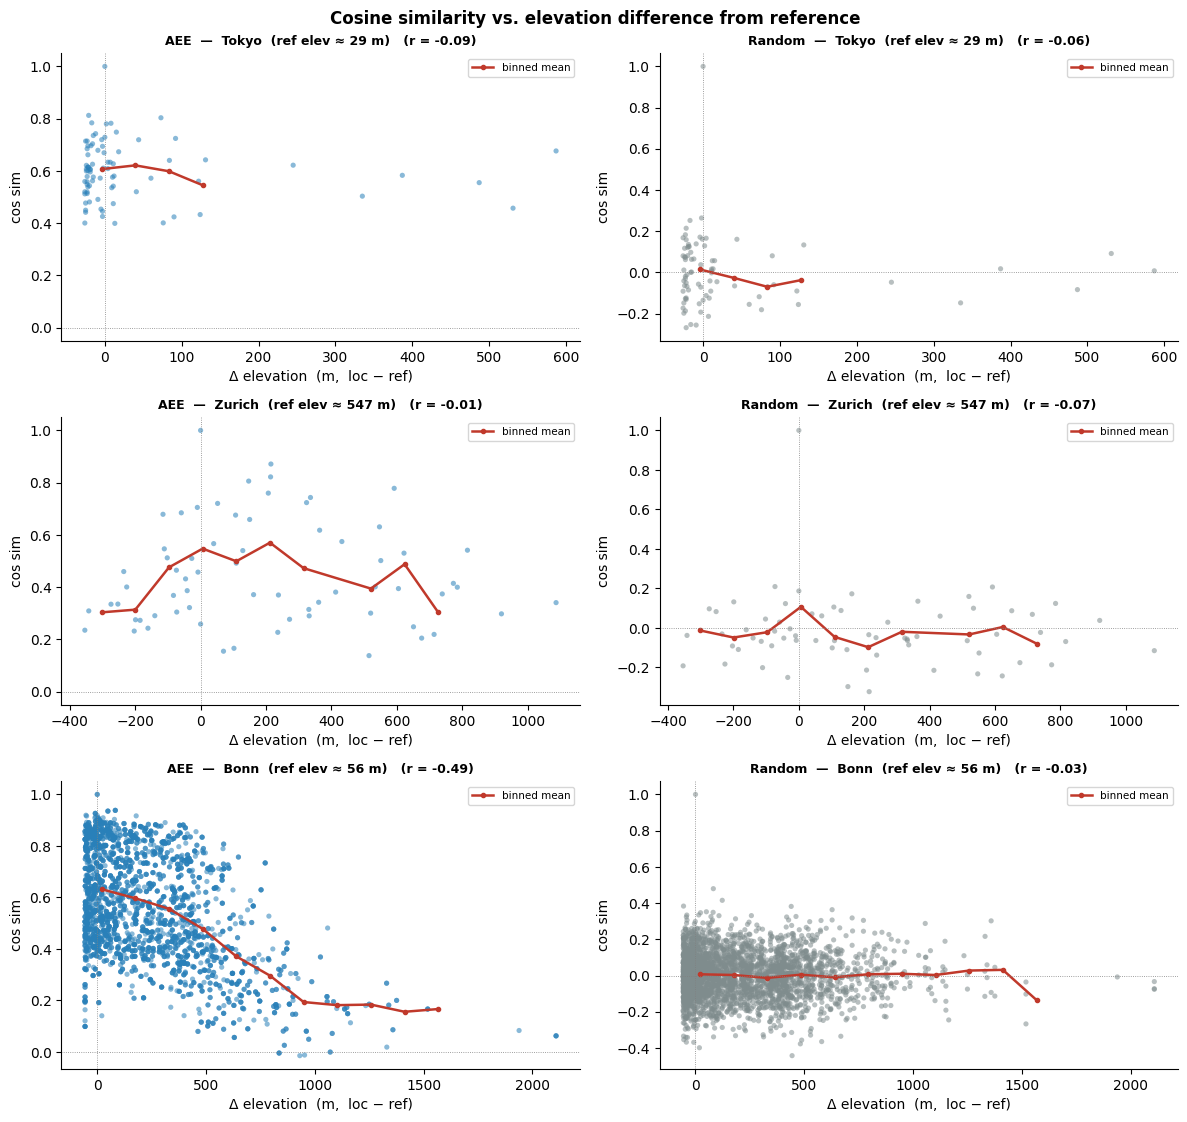

In [7]:
def plot_cosim_vs_elev(ax, scope_mask, ref_ix, emb_key, title, color):
    d = df_loc[scope_mask & df_loc['elev'].notna()].reset_index(drop=True)
    if len(d) < 2:
        ax.set_title(f'{title}: insufficient data'); ax.axis('off'); return None
    ref_vec  = df_loc.loc[ref_ix, emb_key]
    ref_elev = df_loc.loc[ref_ix, 'elev']
    mat = np.stack(d[emb_key].values)
    sims = cos_sim(ref_vec, mat)
    dz = d['elev'].values - ref_elev

    ax.scatter(dz, sims, s=14, alpha=0.55, color=color, edgecolors='none')

    # Binned mean to show trend
    bins = np.linspace(dz.min(), dz.max(), 15)
    xs, ys = [], []
    for lo_b, hi_b in zip(bins[:-1], bins[1:]):
        m = (dz >= lo_b) & (dz < hi_b)
        if m.sum() > 2:
            xs.append((lo_b + hi_b)/2); ys.append(sims[m].mean())
    if xs:
        ax.plot(xs, ys, color='#c0392b', lw=1.8, marker='o', ms=3, label='binned mean')
        ax.legend(fontsize=7.5, loc='best')

    rho = float(np.corrcoef(dz, sims)[0, 1]) if dz.size > 1 else float('nan')
    ax.axhline(0, color='grey', lw=0.6, ls=':')
    ax.axvline(0, color='grey', lw=0.6, ls=':')
    ax.set_xlabel('Δ elevation  (m,  loc − ref)'); ax.set_ylabel('cos sim')
    ax.set_title(f'{title}   (r = {rho:+.2f})', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)


fig, axes = plt.subplots(len(REFERENCES), 2,
                          figsize=(12, 3.8 * len(REFERENCES)), squeeze=False)
fig.suptitle('Cosine similarity vs. elevation difference from reference',
             fontsize=12, fontweight='bold')

for row_ix, (name, lat, lon, scope) in enumerate(REFERENCES):
    mask = scope & has_aee & df_loc['elev'].notna()
    if mask.sum() < 2:
        for c in (0, 1):
            axes[row_ix, c].set_title(f'{name}: insufficient AEE/elev coverage', fontsize=9)
            axes[row_ix, c].axis('off')
        continue
    ref_ix = nearest_loc(lat, lon, mask=mask)
    ref = df_loc.loc[ref_ix]
    subtitle = f'{name}  (ref elev ≈ {ref.elev:.0f} m)'
    plot_cosim_vs_elev(axes[row_ix, 0], mask, ref_ix, 'aee',
                       f'AEE  —  {subtitle}', color='#2980b9')
    plot_cosim_vs_elev(axes[row_ix, 1], mask, ref_ix, 'rand',
                       f'Random  —  {subtitle}', color='#7f8c8d')

plt.tight_layout(); plt.show()

## 5. 2D PCA projection coloured by latitude

Each point = one location's 64-D embedding projected to 2D via PCA.
AEE should show a lat/lon gradient; Random should be a diffuse cloud.

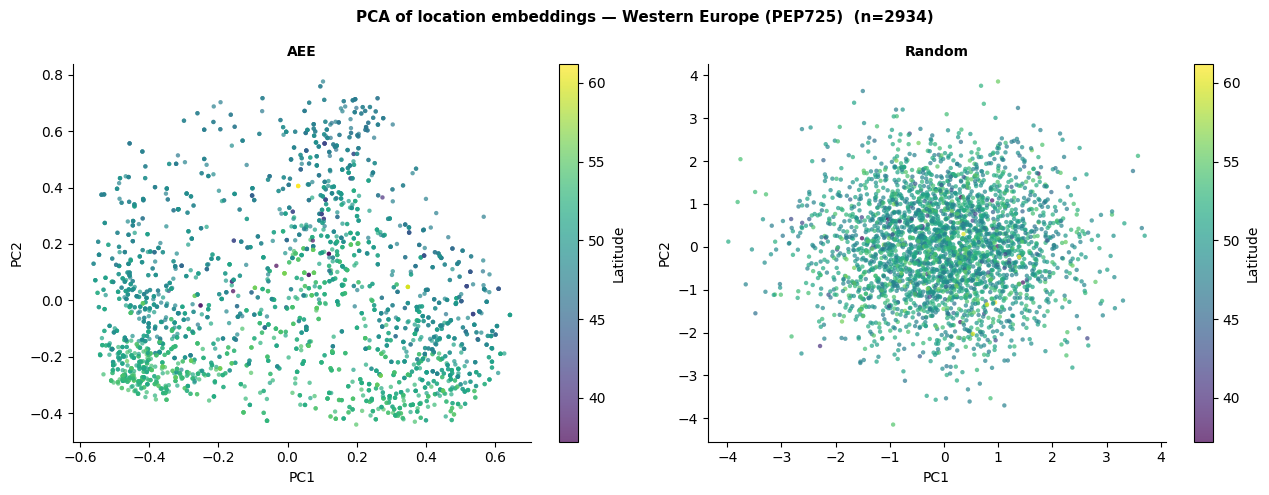

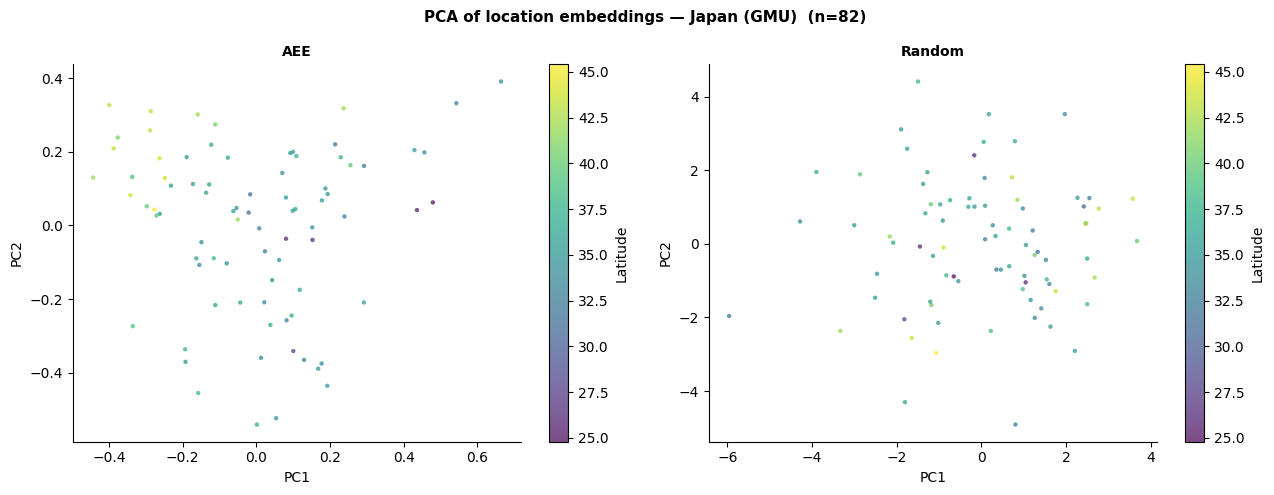

In [8]:
def pca_scatter(ax, vectors, lats, title):
    mask = ~np.isnan(vectors).any(axis=1)
    if mask.sum() < 3:
        ax.set_title(f'{title}: insufficient data'); ax.axis('off'); return None
    proj = PCA(n_components=2).fit_transform(vectors[mask])
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=lats[mask],
                    cmap='viridis', s=10, alpha=0.7, edgecolors='none')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    return sc


SCOPES = [
    ('Western Europe (PEP725)', df_loc['dataset'].str.startswith('PEP725')),
    ('Japan (GMU)',             df_loc['dataset'].eq('GMU_Cherry_Japan')),
]

for name, mask in SCOPES:
    m = mask & has_aee
    if m.sum() < 5: continue
    d = df_loc[m]
    aee_mat  = np.stack(d['aee'].values)
    rand_mat = np.stack(d['rand'].values)
    lats     = d['lat'].values

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'PCA of location embeddings — {name}  (n={m.sum()})',
                 fontsize=11, fontweight='bold')
    sc1 = pca_scatter(axes[0], aee_mat,  lats, 'AEE')
    sc2 = pca_scatter(axes[1], rand_mat, lats, 'Random')
    if sc1 is not None: plt.colorbar(sc1, ax=axes[0], label='Latitude')
    if sc2 is not None: plt.colorbar(sc2, ax=axes[1], label='Latitude')
    plt.tight_layout(); plt.show()

## 6. Similarity vs. geographic distance

Does embedding similarity decay with geographic distance? A strong decay
means the embedding carries a spatial signal that a random baseline
cannot replicate.

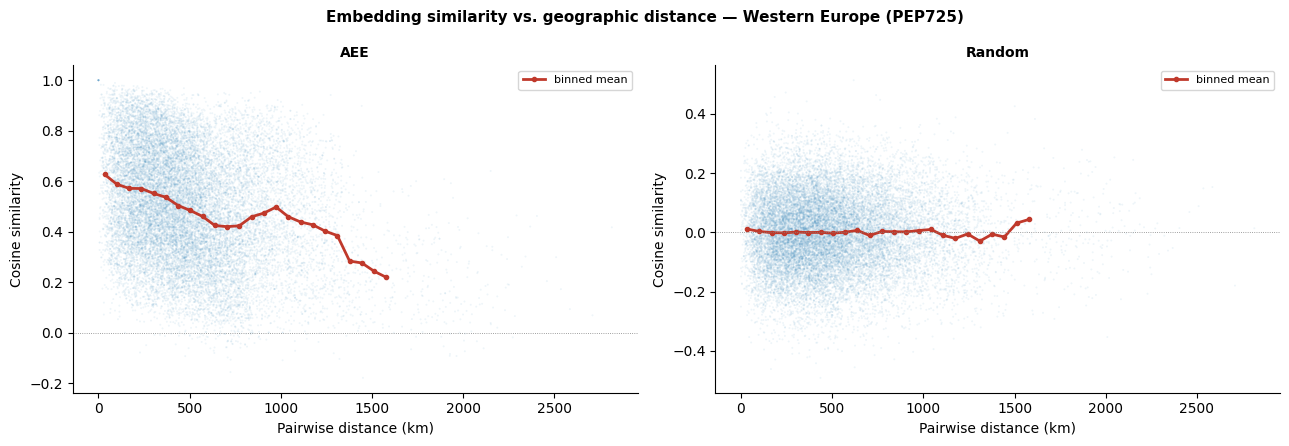

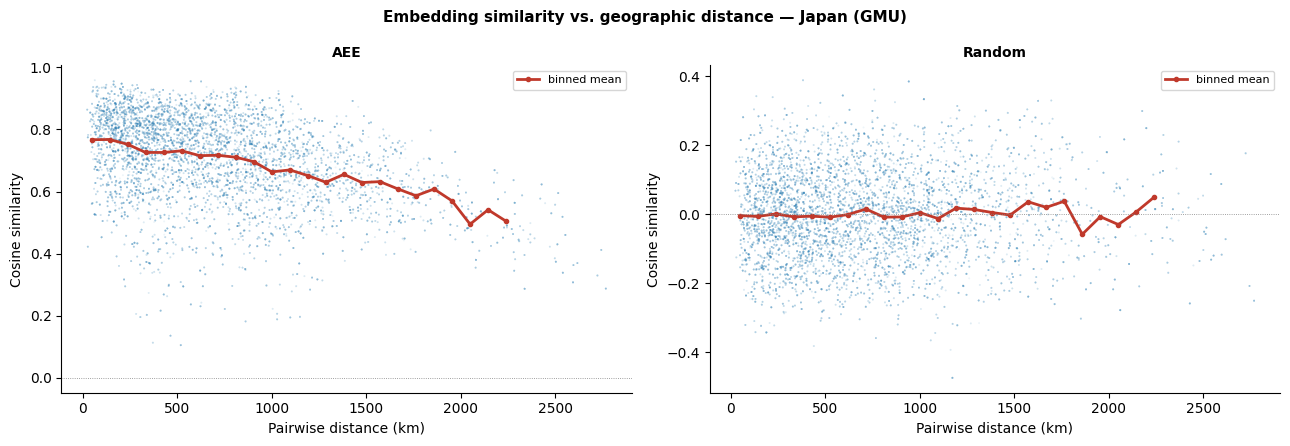

In [9]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    dlat = lat2r - lat1r
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def pairwise_decay(ax, vectors, lats, lons, title, max_pairs=20_000):
    mask = ~np.isnan(vectors).any(axis=1)
    v  = vectors[mask]
    la = lats[mask]; lo = lons[mask]
    n = len(v)
    if n < 10:
        ax.set_title(f'{title}: insufficient data'); ax.axis('off'); return
    vn = v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-12)
    rng = np.random.default_rng(0)
    idx_a = rng.integers(0, n, size=max_pairs)
    idx_b = rng.integers(0, n, size=max_pairs)
    keep  = idx_a != idx_b
    idx_a, idx_b = idx_a[keep], idx_b[keep]
    sims = (vn[idx_a] * vn[idx_b]).sum(axis=1)
    dist = haversine_km(la[idx_a], lo[idx_a], la[idx_b], lo[idx_b])

    ax.scatter(dist, sims, s=2, alpha=0.08, color='#2980b9', edgecolors='none')
    bins = np.linspace(0, np.percentile(dist, 99), 25)
    xs, ys = [], []
    for lo_b, hi_b in zip(bins[:-1], bins[1:]):
        m = (dist >= lo_b) & (dist < hi_b)
        if m.sum() > 10:
            xs.append((lo_b + hi_b)/2); ys.append(sims[m].mean())
    if xs:
        ax.plot(xs, ys, color='#c0392b', lw=2, marker='o', ms=3, label='binned mean')
        ax.legend(fontsize=8)
    ax.axhline(0, color='grey', lw=0.6, ls=':')
    ax.set_xlabel('Pairwise distance (km)'); ax.set_ylabel('Cosine similarity')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)


for name, mask in SCOPES:
    m = mask & has_aee
    if m.sum() < 10: continue
    d = df_loc[m]
    lats, lons = d['lat'].values, d['lon'].values
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f'Embedding similarity vs. geographic distance — {name}',
                 fontsize=11, fontweight='bold')
    pairwise_decay(axes[0], np.stack(d['aee'].values),  lats, lons, 'AEE')
    pairwise_decay(axes[1], np.stack(d['rand'].values), lats, lons, 'Random')
    plt.tight_layout(); plt.show()

## 7. Pairwise similarity matrix (Japan sample)

For a manageable subset (Japan stations sorted N→S), the full pairwise
cosine-similarity matrix. Block/gradient structure = geographic coherence.

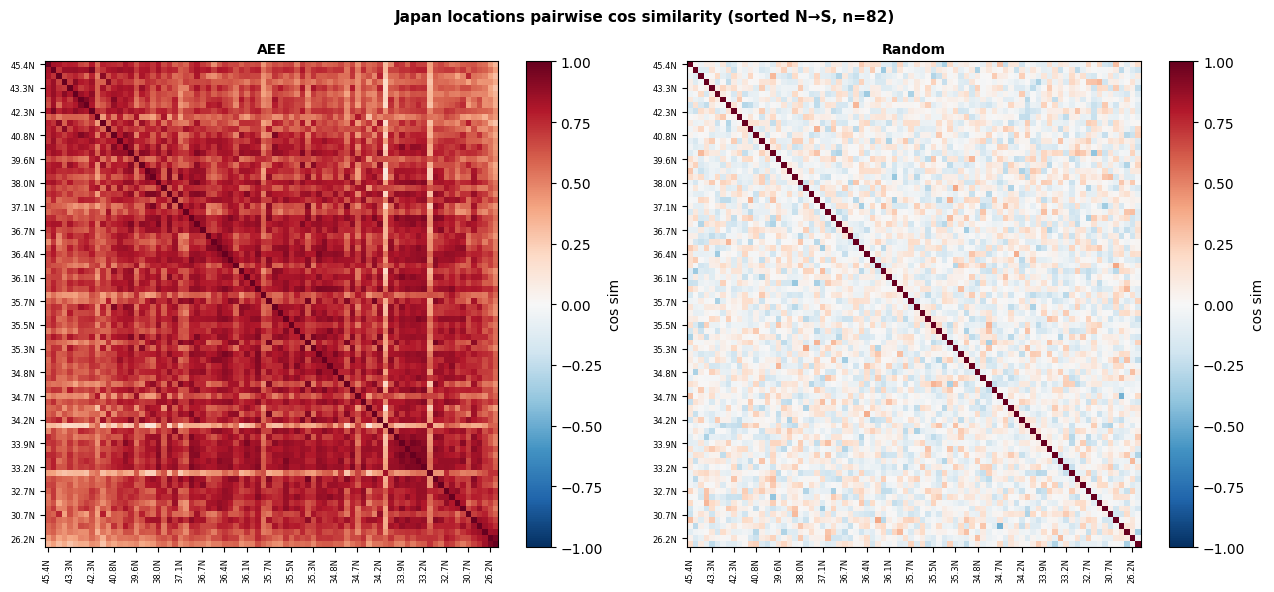

In [10]:
def similarity_matrix(ax, vectors, labels, title):
    vn = vectors / (np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12)
    S = vn @ vn.T
    im = ax.imshow(S, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(title, fontsize=10, fontweight='bold')
    step = max(1, len(labels) // 20)
    ax.set_xticks(range(0, len(labels), step))
    ax.set_xticklabels(labels[::step], rotation=90, fontsize=6)
    ax.set_yticks(range(0, len(labels), step))
    ax.set_yticklabels(labels[::step], fontsize=6)
    return im

mask = df_loc['dataset'].eq('GMU_Cherry_Japan') & has_aee
d = df_loc[mask].sort_values('lat', ascending=False).reset_index(drop=True)
if len(d):
    aee_mat  = np.stack(d['aee'].values)
    rand_mat = np.stack(d['rand'].values)
    labels   = [f'{r.lat:.1f}N' for r in d.itertuples()]
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle(f'Japan locations pairwise cos similarity (sorted N→S, n={len(d)})',
                 fontsize=11, fontweight='bold')
    im1 = similarity_matrix(axes[0], aee_mat,  labels, 'AEE')
    im2 = similarity_matrix(axes[1], rand_mat, labels, 'Random')
    plt.colorbar(im1, ax=axes[0], label='cos sim')
    plt.colorbar(im2, ax=axes[1], label='cos sim')
    plt.tight_layout(); plt.show()

## 8. Embedding structure vs. (lat, lon, elevation)

Directly test whether AEE structure aligns with each of the three hand-crafted
geographic features. A higher **Spearman correlation** between the top PCA
component of the embedding and a feature means the embedding already carries
that information.


Western Europe (PEP725)  (n=2934)


,AEE max |ρ|,Random max |ρ|
feature,,
lat,0.633,0.023
lon,0.254,0.039
elev,0.729,0.037


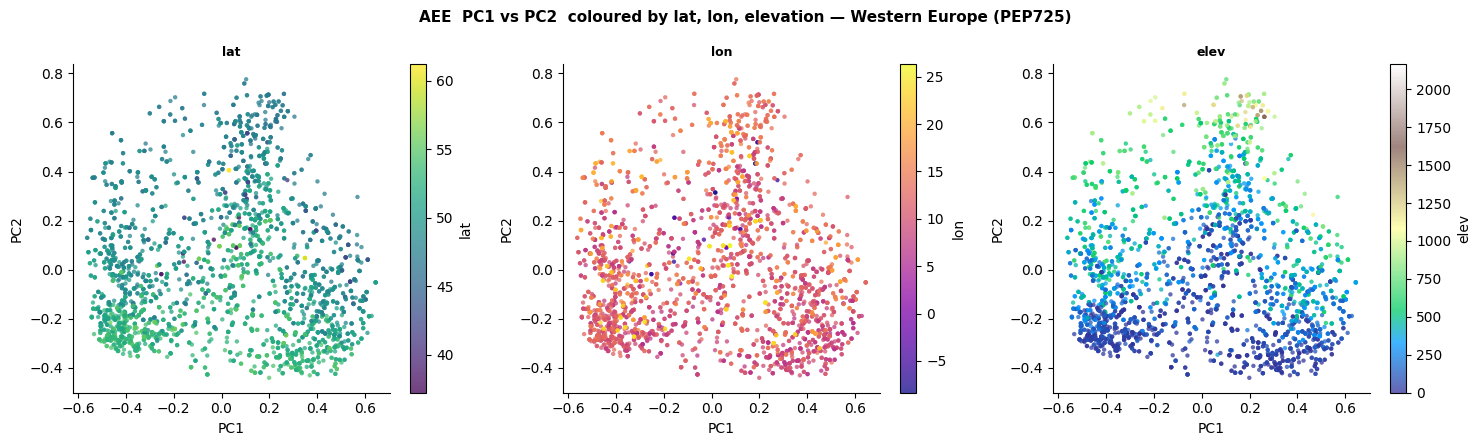


Japan (GMU)  (n=82)


,AEE max |ρ|,Random max |ρ|
feature,,
lat,0.622,0.063
lon,0.593,0.051
elev,0.211,0.196


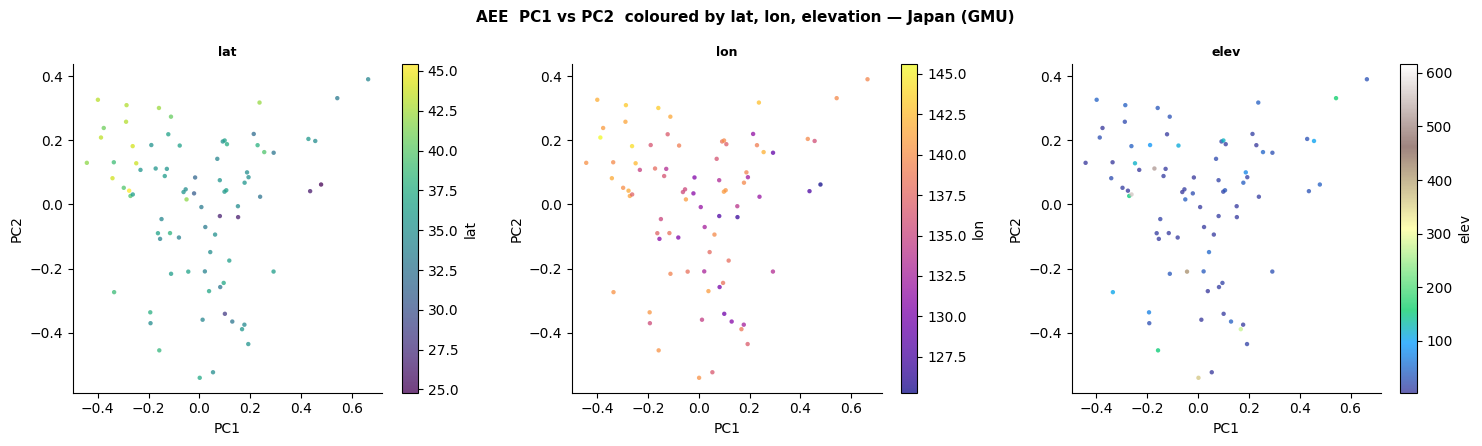

In [11]:
from scipy.stats import spearmanr

FEATURES = ['lat', 'lon', 'elev']

for name, mask in SCOPES:
    m = mask & has_aee & df_loc['elev'].notna()
    if m.sum() < 10:
        continue
    d = df_loc[m]
    aee_mat  = np.stack(d['aee'].values)
    rand_mat = np.stack(d['rand'].values)

    # Top-3 PCA components of each embedding; we'll look at the max |rho|
    pca_aee  = PCA(n_components=3).fit_transform(aee_mat)
    pca_rand = PCA(n_components=3).fit_transform(rand_mat)

    rows = []
    for feat in FEATURES:
        target = d[feat].values
        rho_aee  = max(abs(spearmanr(pca_aee[:,  i], target).correlation) for i in range(3))
        rho_rand = max(abs(spearmanr(pca_rand[:, i], target).correlation) for i in range(3))
        rows.append({'feature': feat, 'AEE max |ρ|': rho_aee, 'Random max |ρ|': rho_rand})
    print(f'\n{name}  (n={m.sum()})')
    display(pd.DataFrame(rows).set_index('feature').round(3))

    # Visual: colour the AEE PCA projection by each of lat/lon/elev
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(f'AEE  PC1 vs PC2  coloured by lat, lon, elevation — {name}',
                 fontsize=11, fontweight='bold')
    for ax, feat, cmap in zip(axes, FEATURES, ['viridis', 'plasma', 'terrain']):
        sc = ax.scatter(pca_aee[:, 0], pca_aee[:, 1], c=d[feat].values,
                        cmap=cmap, s=10, alpha=0.75, edgecolors='none')
        plt.colorbar(sc, ax=ax, label=feat)
        ax.set_title(feat, fontsize=9, fontweight='bold')
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()

## 9. Supervised elevation probe

Directly test whether the AEE vector **contains** elevation information,
by training a regressor `embedding → elevation` with k-fold CV.

- A high **R²** on held-out folds means elevation is linearly decodable
  from the 64-D vector — even if cos-sim alone doesn't reveal it.
- The **Random** baseline should fail (R² ≈ 0) because per-location
  random vectors carry no information that transfers to held-out sites.
- **MAE** is compared against the naive 'always predict the mean'
  baseline so you can see the absolute-meters improvement.

This is the standard 'does the representation contain X?' test and is
much more sensitive than the cos-sim view in §4b.

== Western Europe (PEP725) (n=2934, elev -1–2165 m) ==
   Naive (predict mean) MAE = 214.0 m


R² (5-fold) MAE (m) MAE vs naive
embedding probe                                                  
AEE       Linear (Ridge α=1)  +0.942 ± 0.008    46.3        0.22×
          k-NN (k=5)          +0.870 ± 0.006    61.2        0.29×
Random    Linear (Ridge α=1)  -0.024 ± 0.014   215.7        1.01×
          k-NN (k=5)          -0.222 ± 0.062   232.2        1.08×

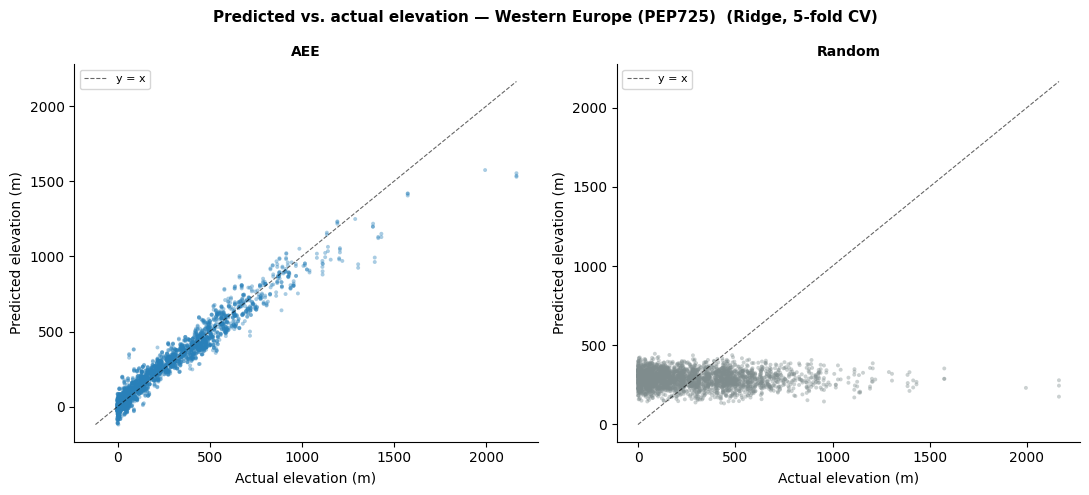

== Japan (GMU) (n=82, elev 3–616 m) ==
   Naive (predict mean) MAE = 71.6 m


R² (5-fold) MAE (m) MAE vs naive
embedding probe                                                  
AEE       Linear (Ridge α=1)  +0.044 ± 0.313    63.9        0.89×
          k-NN (k=5)          -0.196 ± 0.700    62.2        0.87×
Random    Linear (Ridge α=1)  -4.016 ± 6.439   142.9        2.00×
          k-NN (k=5)          -0.142 ± 0.160    69.2        0.97×

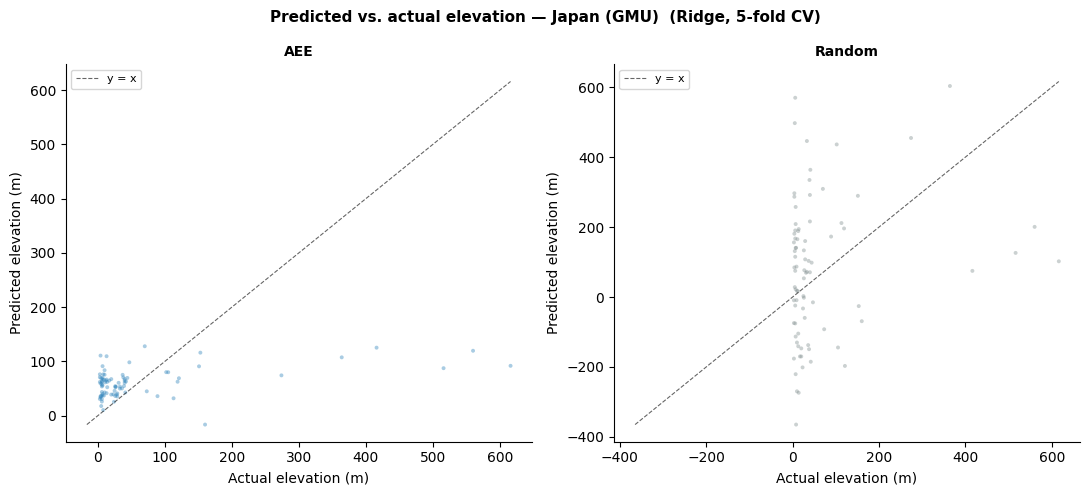

In [13]:
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_predict

PROBES = [
    ('Linear (Ridge α=1)', lambda: Ridge(alpha=1.0)),
    ('k-NN (k=5)',         lambda: KNeighborsRegressor(n_neighbors=5)),
]

def probe_elev(vectors, elev, n_splits=5, seed=0):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    out = {}
    for name, factory in PROBES:
        r2s, maes = [], []
        for tr, te in kf.split(vectors):
            m = factory().fit(vectors[tr], elev[tr])
            pred = m.predict(vectors[te])
            ss_res = float(((elev[te] - pred)**2).sum())
            ss_tot = float(((elev[te] - elev[te].mean())**2).sum())
            r2s.append(1 - ss_res/ss_tot if ss_tot > 0 else float('nan'))
            maes.append(float(np.abs(elev[te] - pred).mean()))
        out[name] = (float(np.nanmean(r2s)), float(np.nanstd(r2s)), float(np.mean(maes)))
    return out


for name, mask in SCOPES:
    m = mask & has_aee & df_loc['elev'].notna()
    if m.sum() < 50:
        print(f'[skip] {name}: only {m.sum()} usable points'); continue
    d = df_loc[m]
    aee_mat  = np.stack(d['aee'].values)
    rand_mat = np.stack(d['rand'].values)
    elev     = d['elev'].values.astype(np.float32)

    naive_mae = float(np.abs(elev - elev.mean()).mean())
    print(f'== {name} (n={m.sum()}, elev {elev.min():.0f}–{elev.max():.0f} m) ==')
    print(f'   Naive (predict mean) MAE = {naive_mae:.1f} m')

    rows = []
    for emb_label, mat in [('AEE', aee_mat), ('Random', rand_mat)]:
        for probe_name, (r2_m, r2_s, mae) in probe_elev(mat, elev).items():
            rows.append({
                'embedding': emb_label,
                'probe':     probe_name,
                'R² (5-fold)': f'{r2_m:+.3f} ± {r2_s:.3f}',
                'MAE (m)':    f'{mae:.1f}',
                'MAE vs naive': f'{mae/naive_mae:.2f}×',
            })
    display(pd.DataFrame(rows).set_index(['embedding', 'probe']))

    # Predicted vs actual elevation for the AEE Ridge probe
    pred_aee  = cross_val_predict(Ridge(alpha=1.0), aee_mat,  elev, cv=5)
    pred_rand = cross_val_predict(Ridge(alpha=1.0), rand_mat, elev, cv=5)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle(f'Predicted vs. actual elevation — {name}  (Ridge, 5-fold CV)',
                 fontsize=11, fontweight='bold')
    for ax, pred, label, color in [
        (axes[0], pred_aee,  'AEE',    '#2980b9'),
        (axes[1], pred_rand, 'Random', '#7f8c8d'),
    ]:
        ax.scatter(elev, pred, s=8, alpha=0.4, color=color, edgecolors='none')
        lo = min(float(elev.min()), float(pred.min()))
        hi = max(float(elev.max()), float(pred.max()))
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.6, label='y = x')
        ax.set_xlabel('Actual elevation (m)')
        ax.set_ylabel('Predicted elevation (m)')
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.legend(fontsize=8, loc='upper left')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()